In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report,confusion_matrix,roc_auc_score,precision_score,recall_score,f1_score)


In [3]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

In [4]:
#LOAD DATA
df = pd.read_csv("train_transaction.csv")
print("Dataset: ")
print(df.head())

Dataset: 
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  117.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
4  514.0  150.0  mastercard  102.0  ...  0.0   0.0   0.0   0.0   0.0  0.0   

  V336  V337  V338  V339  
0  NaN   NaN   NaN   NaN  
1  NaN   N

In [5]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(5900, 394)


In [6]:
print("\nAll Feature Names:")
print(df.columns.tolist())
print("\nNumber of Features:")
print(len(df.columns))
print("\nFeature Information:")
print(df.info())


All Feature Names:
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V7

In [7]:
#Removing duplicates
print("\nDuplicates : " , df.duplicated().sum())


Duplicates :  0


In [8]:
#CHECK FRAUD DISTRIBUTION
print("\nClass Distribution:")
print(df["isFraud"].value_counts())
print("\nClass Percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)


Class Distribution:
isFraud
0    5755
1     145
Name: count, dtype: int64

Class Percentage:
isFraud
0    97.542373
1     2.457627
Name: proportion, dtype: float64


In [9]:
#SEPARATE FEATURES AND TARGET
X = df.drop(columns=["isFraud", "TransactionID"])
y = df["isFraud"]

In [10]:
#KEEP NUMERICAL FEATURES
X = X.select_dtypes(include=np.number)
print("\nNumber of numerical features:")
print(X.shape[1])


Number of numerical features:
378


In [11]:
#HANDLE MISSING VALUES
print("\nTotal missing values before:")
print(X.isnull().sum().sum())
# Replace missing values with median
X = X.fillna(X.median())
print("\nTotal missing values after:")
print(X.isnull().sum().sum())


Total missing values before:
1068230

Total missing values after:
0


In [12]:
#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("\nTraining Data Shape:")
print(X_train.shape)
print("\nTesting Data Shape:")
print(X_test.shape)
print("\nTraining Class Distribution:")
print(y_train.value_counts())


Training Data Shape:
(4720, 378)

Testing Data Shape:
(1180, 378)

Training Class Distribution:
isFraud
0    4604
1     116
Name: count, dtype: int64


In [13]:
#SCALE FEATURES
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
#APPLY SMOTE
smote = SMOTE(sampling_strategy=0.5,random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled,y_train)
print("\nClass Distribution After SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Class Distribution After SMOTE:
isFraud
0    4604
1    2302
Name: count, dtype: int64


In [15]:
#TRAIN XGBOOST
xgb_model = XGBClassifier(n_estimators=200,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,random_state=42,eval_metric="logloss")
print("\nTraining XGBoost...")
xgb_model.fit(X_train_smote,y_train_smote)
print("Training Completed.")


Training XGBoost...
Training Completed.


In [16]:
#GET FRAUD PROBABILITIES
y_probability = xgb_model.predict_proba(X_test_scaled)[:, 1]
print("\nFirst 10 Fraud Probabilities:")
print(y_probability[:10])


First 10 Fraud Probabilities:
[0.00382741 0.01025807 0.1443415  0.00715956 0.14597578 0.02647816
 0.02676721 0.01173341 0.02337747 0.00421485]


In [17]:
#DEFAULT THRESHOLD = 0.5
y_pred_05 = (y_probability >= 0.5).astype(int)
print("\nXGBoost Results - Threshold 0.5")
print(classification_report(y_test,y_pred_05,zero_division=0))
print("ROC-AUC:",roc_auc_score(y_test,y_probability))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred_05))


XGBoost Results - Threshold 0.5
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1151
           1       0.69      0.38      0.49        29

    accuracy                           0.98      1180
   macro avg       0.84      0.69      0.74      1180
weighted avg       0.98      0.98      0.98      1180

ROC-AUC: 0.9211779861589622

Confusion Matrix:
[[1146    5]
 [  18   11]]


In [18]:
#TUNE DECISION THRESHOLD
thresholds = np.arange(0.1,0.91,0.05)
results = []
for threshold in thresholds:
    y_pred = (y_probability >= threshold).astype(int)
    precision = precision_score(y_test,y_pred,zero_division=0)
    recall = recall_score(y_test,y_pred,zero_division=0)
    f1 = f1_score(y_test,y_pred,zero_division=0)
    results.append([threshold, precision, recall, f1])
results_df = pd.DataFrame(results,columns=["Threshold","Precision","Recall","F1"])
print("\nThreshold Results:")
print(results_df)


Threshold Results:
    Threshold  Precision    Recall        F1
0        0.10   0.178218  0.620690  0.276923
1        0.15   0.246154  0.551724  0.340426
2        0.20   0.250000  0.448276  0.320988
3        0.25   0.317073  0.448276  0.371429
4        0.30   0.371429  0.448276  0.406250
5        0.35   0.448276  0.448276  0.448276
6        0.40   0.578947  0.379310  0.458333
7        0.45   0.611111  0.379310  0.468085
8        0.50   0.687500  0.379310  0.488889
9        0.55   0.733333  0.379310  0.500000
10       0.60   0.769231  0.344828  0.476190
11       0.65   0.833333  0.344828  0.487805
12       0.70   0.909091  0.344828  0.500000
13       0.75   0.909091  0.344828  0.500000
14       0.80   0.900000  0.310345  0.461538
15       0.85   0.888889  0.275862  0.421053
16       0.90   0.875000  0.241379  0.378378


In [19]:
#BEST THRESHOLD
best_row = results_df.loc[results_df["F1"].idxmax()]
best_threshold = best_row["Threshold"]
print("\nBest Threshold:")
print(best_threshold)
print("\nBest F1 Score:")
print(best_row["F1"])


Best Threshold:
0.5500000000000002

Best F1 Score:
0.5


In [20]:
#FINAL PREDICTION
y_pred = (y_probability >= best_threshold).astype(int)

In [21]:
# FINAL EVALUATION
print("\nFinal XGBoost Results:")
print(classification_report(y_test,y_pred,zero_division=0))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test,y_pred))
print("\nROC-AUC:",roc_auc_score(y_test,y_probability))
print("Precision:",precision_score(y_test,y_pred,zero_division=0))
print("Recall:",recall_score(y_test,y_pred,zero_division=0))
print("F1 Score:",f1_score(y_test,y_pred,zero_division=0))


Final XGBoost Results:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1151
           1       0.73      0.38      0.50        29

    accuracy                           0.98      1180
   macro avg       0.86      0.69      0.75      1180
weighted avg       0.98      0.98      0.98      1180


Confusion Matrix:
[[1147    4]
 [  18   11]]

ROC-AUC: 0.9211779861589622
Precision: 0.7333333333333333
Recall: 0.3793103448275862
F1 Score: 0.5


In [22]:
#FEATURE IMPORTANCE
importance = pd.Series(xgb_model.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)
print("\nTop 10 Important Features:")
print(importance.head(10))


Top 10 Important Features:
V29      0.056938
C5       0.050169
D8       0.045977
V218     0.043152
card3    0.031256
C11      0.031026
V317     0.028962
V292     0.025588
C2       0.022536
V160     0.020529
dtype: float32


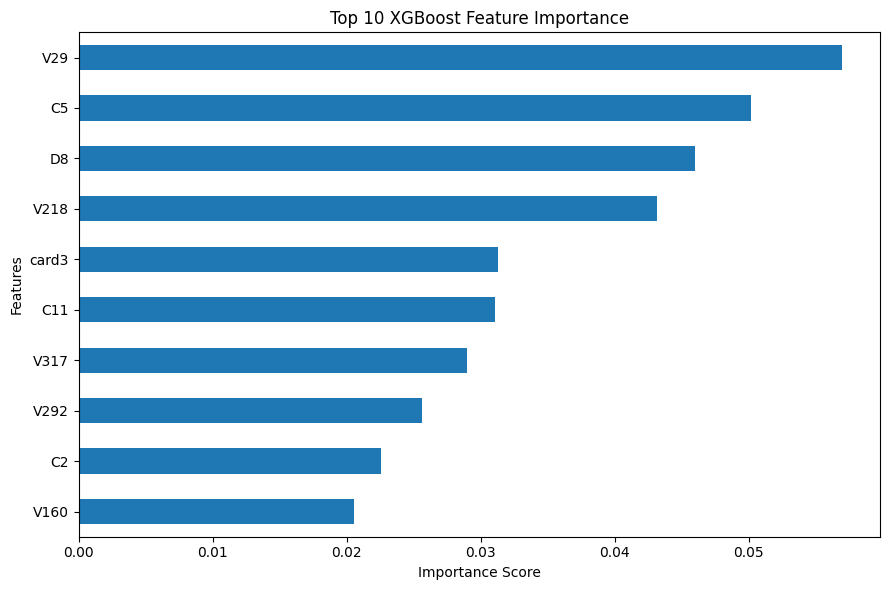

In [23]:
#Feature Ploting
top_features = importance.head(10)
plt.figure(figsize=(9, 6))
top_features.sort_values().plot(kind="barh")
plt.title("Top 10 XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("top_features.png",dpi=300,bbox_inches="tight")
plt.show()

In [24]:
#Saving Final Predictions
prediction_df = pd.DataFrame({"Actual_Class": y_test.values,"Predicted_Class": y_pred,"Fraud_Probability": y_probability})
prediction_df.to_csv("final_fraud_predictions.csv",index=False)
print("Final predictions saved successfully!")
print("File: final_fraud_predictions.csv")
display(prediction_df.head())

Final predictions saved successfully!
File: final_fraud_predictions.csv


,Actual_Class,Predicted_Class,Fraud_Probability
0,0,0,0.003827
1,0,0,0.010258
2,0,0,0.144341
3,0,0,0.007160
4,0,0,0.145976
